In [20]:
%pip install pandas scikit-learn matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

print("It worked. Ethan is amazing.")

Note: you may need to restart the kernel to use updated packages.
It worked. Ethan is amazing.


In [21]:
# Load the stock data into a Pandas DataFrame
df = pd.read_csv('nifty500_5yr_data.csv') 

# Clean up data by dropping any blank rows
df = df.dropna()

# Show the first 5 rows of the data to verify it loaded
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Notes
903,2025-02-01,360ONE,992.996764,1014.184021,979.478244,1006.416992,228332.0,Union Budget Day (Special Trading Session)
2136,2025-02-01,3MINDIA,29164.029400,29640.838914,28460.710403,29391.324219,7488.0,Union Budget Day (Special Trading Session)
3370,2025-02-01,ABB,5848.935670,5872.054678,5340.117787,5433.483398,510445.0,Union Budget Day (Special Trading Session)
4604,2025-02-01,ACC,2001.918974,2021.241002,1942.160198,1993.005005,271590.0,Union Budget Day (Special Trading Session)
4989,2025-02-01,ACMESOLAR,215.503633,232.771876,212.928383,217.669662,1702308.0,Union Budget Day (Special Trading Session)


In [22]:
# X = the features (the clues we give the AI)
X = df[['Open', 'High', 'Low']]

# y = the target (the final answer we want the AI to guess)
y = df['Close']

# Split data: 80% to train the AI, 20% to test it later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split successfully!")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Data split successfully!
Training set size: 372 rows
Testing set size: 93 rows


In [23]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using our training data
model.fit(X_train, y_train)

print("Training complete! The AI has successfully learned the patterns.")

Training complete! The AI has successfully learned the patterns.


In [24]:
# Ask the AI to predict the closing prices for the test data
predictions = model.predict(X_test)

# Calculate the average error (Mean Absolute Error)
error = mean_absolute_error(y_test, predictions)
print(f"On average, the AI's prediction is off by only: {error:.2f} points.")

On average, the AI's prediction is off by only: 37.71 points.


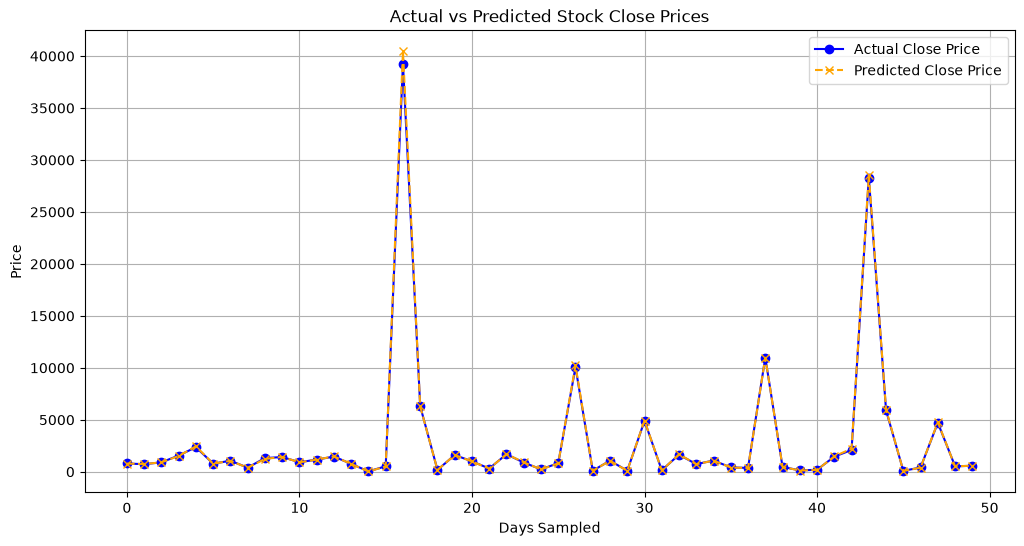

In [25]:
# Plot a comparison chart for the first 50 test samples
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Close Price', color='blue', marker='o')
plt.plot(predictions[:50], label='Predicted Close Price', color='orange', linestyle='--', marker='x')

# Chart labels and styling
plt.title('Actual vs Predicted Stock Close Prices')
plt.xlabel('Days Sampled')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Create and Train the 'Smarter' Random Forest model
# (This uses the exact same data as before)
smart_model = RandomForestRegressor(n_estimators=50, random_state=42)
smart_model.fit(X_train, y_train)

# Generate predictions from the new 'smart' model
smart_predictions = smart_model.predict(X_test)

# Calculate the error for both, so we have the numbers
linear_error = mean_absolute_error(y_test, predictions) # Predictions from earlier
smart_error = mean_absolute_error(y_test, smart_predictions)

print(f"Numbers calculated!")

Numbers calculated!


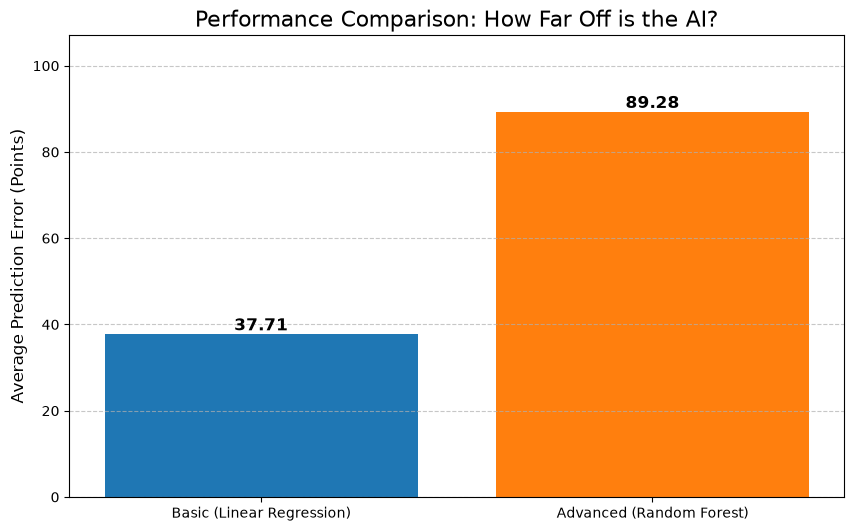

In [27]:
# Define the data for the bar chart
model_names = ['Basic (Linear Regression)', 'Advanced (Random Forest)']
error_values = [linear_error, smart_error]

# Set up the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, error_values, color=['#1f77b4', '#ff7f0e']) # Blue and Orange

# Adding visual flair
plt.title('Performance Comparison: How Far Off is the AI?', fontsize=16)
plt.ylabel('Average Prediction Error (Points)', fontsize=12)
plt.ylim(0, max(error_values) * 1.2) # Give some space at the top
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact number label on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()